In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Bio import SeqIO

import SBM.utils.utils as ut

In [17]:
model_root_folder = Path("../models/")

model_files = []

for model_filename in model_root_folder.glob("FullShuffling_*_Step10/*.npy"):
    model_filestem = model_filename.stem
    model_params = model_filestem.split("_")
    subaln_index = int(model_params[1].replace("SubAln", ""))
    step_index = int(model_params[2].replace("Step", ""))
    replicate = int(model_params[-1].replace("R", ""))

    # for each folder there is just one model
    model_files.append({
        'subaln_index': subaln_index,
        'step_index': step_index,
        'replicate': replicate,
        'model_file': str(model_filename)
    })

df_models = pd.DataFrame(model_files)
idx = df_models.groupby(['step_index', 'subaln_index'])['replicate'].idxmax()
df_models = df_models.loc[idx, ['step_index', 'subaln_index', 'model_file']].reset_index(drop=True)\
    .sort_values(["step_index", "subaln_index"])\
    .set_index(["step_index", "subaln_index"])

In [18]:
def compensatory_ddes(J, i = 197, j = 237, alpha = 3, beta = 16, gamma = 6):
    delta = np.arange(21)    # all amino-acid indices

    DeltaDeltaE = ( J[i, j, alpha, delta] + J[i, j, beta, gamma]
                  - J[i, j, beta, delta] - J[i, j, alpha, gamma] )
    
    return DeltaDeltaE

In [19]:
for model_file in df_models.loc[step_index]["model_file"].values:
    model = np.load(model_file, allow_pickle=True).item()
    try:
        model = np.load(model_file, allow_pickle=True).item()
    except:
        print(model_file + " has a problem")

In [20]:
comp_ddes_list = []
for model_file in df_models.loc[step_index]["model_file"].values:
    try:
        model = np.load(model_file, allow_pickle=True).item()
    except:
        continue
    J, h = ut.Zero_Sum_Gauge(model["J"], model["h"])
    comp_ddes = (compensatory_ddes(J, i = 197, j = 237, alpha = 3, beta = 16, gamma = 6).ravel())
    comp_ddes_list.append(comp_ddes)

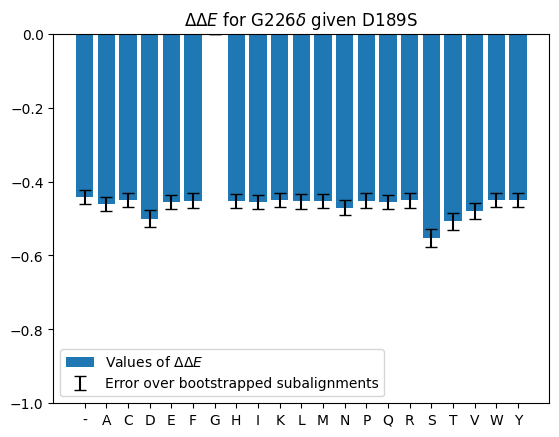

In [23]:
fig = plt.figure()
plt.bar(
    np.arange(21),
    np.mean(comp_ddes_list, axis=0),
    label=r"Values of $\Delta\Delta E$"
)
plt.errorbar(np.arange(21),
    np.mean(comp_ddes_list, axis=0),
    yerr=np.std(comp_ddes_list, axis=0) / np.sqrt(len(comp_ddes_list)),
    capsize=4,
    label="Error over bootstrapped subalignments",
    linestyle="none",
    color="black"
)
plt.ylim([-1., 0.])
plt.title(fr"$\Delta \Delta E$ for G226$\delta$ given D189S")
plt.xticks(ticks=np.arange(21), labels="-ACDEFGHIKLMNPQRSTVWY")
plt.legend()
plt.show()